# 04 智能推荐系统

本部分基于用户浏览、加购和购买行为构建简单的商品推荐模型。首先采用热门商品作为基线方法，再使用 ItemCF 进行个性化推荐，并通过简单的离线指标评价推荐效果。

In [1]:
import duckdb
import pandas as pd

data_path = '../data/processed/ecommerce_clean.parquet'

In [2]:
query = f"""
SELECT
    event_type,
    COUNT(*) AS event_count
FROM '{data_path}'
GROUP BY event_type
ORDER BY event_count DESC
"""

behavior_counts = duckdb.sql(query).df()
behavior_counts

,event_type,event_count
0,view,104331840
1,cart,3828449
2,purchase,1659703


## 用户行为权重

考虑到浏览、加购和购买行为反映的用户兴趣强度不同，为三类行为设置简单权重：浏览为 1，加购为 3，购买为 5，用于后续计算用户对商品的兴趣得分。

In [3]:
query = f"""
SELECT
    user_id,
    product_id,
    SUM(
        CASE
            WHEN event_type = 'view' THEN 1
            WHEN event_type = 'cart' THEN 3
            WHEN event_type = 'purchase' THEN 5
            ELSE 0
        END
    ) AS interest_score
FROM '{data_path}'
GROUP BY user_id, product_id
ORDER BY interest_score DESC
LIMIT 10
"""

top_interactions = duckdb.sql(query).df()
top_interactions

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,user_id,product_id,interest_score
0,564068124,1004833,2504.0
1,523974502,5100563,2232.0
2,564068124,1004767,1777.0
3,549030056,1004856,1482.0
4,543128872,4804056,1444.0
5,535658024,1002544,1350.0
6,541510103,1004833,1309.0
7,518514099,1005116,1296.0
8,512386086,1801555,1244.0
9,552639168,4100346,1205.0


## 热门商品推荐 Baseline

首先根据用户行为权重计算商品的整体热度，并选取热度最高的商品作为基础推荐结果。该方法不考虑用户个性化偏好，主要作为后续 ItemCF 推荐效果的对照基线。

In [4]:
query = f"""
SELECT
    product_id,
    COUNT(DISTINCT user_id) AS user_count,
    SUM(
        CASE
            WHEN event_type = 'view' THEN 1
            WHEN event_type = 'cart' THEN 3
            WHEN event_type = 'purchase' THEN 5
            ELSE 0
        END
    ) AS popularity_score
FROM '{data_path}'
GROUP BY product_id
ORDER BY popularity_score DESC
LIMIT 10
"""

popular_products = duckdb.sql(query).df()
popular_products

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,product_id,user_count,popularity_score
0,1004856,415235,1628935.0
1,1004767,370099,1378115.0
2,1005115,372130,1320512.0
3,4804056,154799,875231.0
4,1004833,209924,741782.0
5,1004870,185316,725454.0
6,1004249,190173,667955.0
7,1005105,240113,648182.0
8,1002544,194813,647931.0
9,1005160,149218,570186.0


补充热门商品信息

In [5]:
product_info_query = f"""
SELECT
    product_id,
    MODE(category_code) AS category_code,
    MODE(brand) AS brand,
    ROUND(AVG(price), 2) AS avg_price
FROM '{data_path}'
WHERE product_id IN (
    SELECT product_id
    FROM (
        SELECT
            product_id,
            SUM(
                CASE
                    WHEN event_type = 'view' THEN 1
                    WHEN event_type = 'cart' THEN 3
                    WHEN event_type = 'purchase' THEN 5
                    ELSE 0
                END
            ) AS popularity_score
        FROM '{data_path}'
        GROUP BY product_id
        ORDER BY popularity_score DESC
        LIMIT 10
    )
)
GROUP BY product_id
"""

product_info = duckdb.sql(product_info_query).df()

popular_products_detail = popular_products.merge(
    product_info,
    on="product_id",
    how="left"
)

popular_products_detail

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,product_id,user_count,popularity_score,category_code,brand,avg_price
0,1004856,415235,1628935.0,electronics.smartphone,samsung,129.02
1,1004767,370099,1378115.0,electronics.smartphone,samsung,247.13
2,1005115,372130,1320512.0,electronics.smartphone,apple,946.31
3,4804056,154799,875231.0,electronics.audio.headphone,apple,162.11
4,1004833,209924,741782.0,electronics.smartphone,samsung,171.29
5,1004870,185316,725454.0,electronics.smartphone,samsung,283.39
6,1004249,190173,667955.0,electronics.smartphone,apple,750.40
7,1005105,240113,648182.0,electronics.smartphone,apple,1373.81
8,1002544,194813,647931.0,electronics.smartphone,apple,469.13
9,1005160,149218,570186.0,electronics.smartphone,xiaomi,208.83


## ItemCF 数据准备

由于原始用户行为数据规模较大，直接构建完整用户-商品矩阵会占用较多内存。因此先对用户和商品交互规模进行统计，再筛选具有一定活跃度的用户和商品用于 ItemCF 建模。

In [6]:
query = f"""
SELECT
    user_id,
    COUNT(*) AS interaction_count
FROM '{data_path}'
GROUP BY user_id
"""

user_activity = duckdb.sql(query).df()

user_activity["interaction_count"].describe(
    percentiles=[0.5, 0.75, 0.9, 0.95, 0.99]
).round(2)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

count    5316649.00
mean          20.66
std           53.87
min            1.00
50%            5.00
75%           18.00
90%           51.00
95%           88.00
99%          225.00
max        22925.00
Name: interaction_count, dtype: float64

In [7]:
active_user_count = (
    user_activity["interaction_count"] >= 20
).sum()

active_user_ratio = (
    active_user_count / len(user_activity) * 100
)

print(f"活跃用户数：{active_user_count:,}")
print(f"占全部用户比例：{active_user_ratio:.2f}%")

活跃用户数：1,266,014
占全部用户比例：23.81%


统计商品交互量分布

In [8]:
query = f"""
SELECT
    product_id,
    COUNT(*) AS interaction_count,
    COUNT(DISTINCT user_id) AS user_count
FROM '{data_path}'
GROUP BY product_id
"""

product_activity = duckdb.sql(query).df()

product_activity["user_count"].describe(
    percentiles=[0.5, 0.75, 0.9, 0.95, 0.99]
).round(2)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

count    206876.00
mean        272.49
std        2599.56
min           1.00
50%          34.00
75%         119.00
90%         398.00
95%         852.00
99%        3731.25
max      415235.00
Name: user_count, dtype: float64

确认活跃商品数量

In [9]:
active_product_count = (
    product_activity["user_count"] >= 400
).sum()

active_product_ratio = (
    active_product_count / len(product_activity) * 100
)

print(f"活跃商品数：{active_product_count:,}")
print(f"占全部商品比例：{active_product_ratio:.2f}%")

活跃商品数：20,596
占全部商品比例：9.96%


统计筛选后的交互规模

In [10]:
query = f"""
WITH active_users AS (
    SELECT user_id
    FROM '{data_path}'
    GROUP BY user_id
    HAVING COUNT(*) >= 20
),

active_products AS (
    SELECT product_id
    FROM '{data_path}'
    GROUP BY product_id
    HAVING COUNT(DISTINCT user_id) >= 400
)

SELECT
    COUNT(*) AS event_count,
    COUNT(DISTINCT d.user_id) AS user_count,
    COUNT(DISTINCT d.product_id) AS product_count,
    COUNT(DISTINCT (d.user_id, d.product_id)) AS user_product_pairs
FROM '{data_path}' d
INNER JOIN active_users u
    ON d.user_id = u.user_id
INNER JOIN active_products p
    ON d.product_id = p.product_id
"""

filtered_stats = duckdb.sql(query).df()
filtered_stats

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,event_count,user_count,product_count,user_product_pairs
0,72927793,1264651,20596,33391203


In [11]:
query = f"""
WITH active_users AS (
    SELECT user_id
    FROM '{data_path}'
    GROUP BY user_id
    HAVING COUNT(*) >= 20
),

active_products AS (
    SELECT product_id
    FROM '{data_path}'
    GROUP BY product_id
    HAVING COUNT(DISTINCT user_id) >= 400
)

SELECT
    COUNT(*) AS event_count,
    COUNT(DISTINCT d.user_id) AS user_count,
    COUNT(DISTINCT d.product_id) AS product_count,
    COUNT(DISTINCT (d.user_id, d.product_id)) AS user_product_pairs
FROM '{data_path}' d
INNER JOIN active_users u
    ON d.user_id = u.user_id
INNER JOIN active_products p
    ON d.product_id = p.product_id
WHERE d.event_type IN ('cart', 'purchase')
"""

strong_behavior_stats = duckdb.sql(query).df()
strong_behavior_stats

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,event_count,user_count,product_count,user_product_pairs
0,4082871,681386,20175,1687489


### ItemCF 交互数据构建

在活跃用户和活跃商品的基础上，仅保留加购和购买两类强兴趣行为，并对同一用户与商品的多次行为进行聚合，形成 ItemCF 使用的用户-商品交互数据。

In [12]:
query = f"""
WITH active_users AS (
    SELECT user_id
    FROM '{data_path}'
    GROUP BY user_id
    HAVING COUNT(*) >= 20
),

active_products AS (
    SELECT product_id
    FROM '{data_path}'
    GROUP BY product_id
    HAVING COUNT(DISTINCT user_id) >= 400
)

SELECT
    d.user_id,
    d.product_id,
    SUM(
        CASE
            WHEN d.event_type = 'cart' THEN 1
            WHEN d.event_type = 'purchase' THEN 2
            ELSE 0
        END
    ) AS score
FROM '{data_path}' d
INNER JOIN active_users u
    ON d.user_id = u.user_id
INNER JOIN active_products p
    ON d.product_id = p.product_id
WHERE d.event_type IN ('cart', 'purchase')
GROUP BY d.user_id, d.product_id
"""

interactions = duckdb.sql(query).df()

print("交互数据形状：", interactions.shape)
interactions.head()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

交互数据形状： (1687489, 3)


,user_id,product_id,score
0,540944213,1002923,3.0
1,560127436,47300240,2.0
2,530428772,52100006,1.0
3,550853656,11800029,3.0
4,514567561,18001689,1.0


检查 score 分布

In [13]:
interactions["score"].describe(
    percentiles=[0.5, 0.75, 0.9, 0.95, 0.99]
).round(2)

count    1687489.00
mean           3.14
std            4.25
min            1.00
50%            2.00
75%            3.00
90%            6.00
95%            8.00
99%           17.00
max          803.00
Name: score, dtype: float64

构建二值交互

In [14]:
interactions["interaction"] = 1

interactions.head()

,user_id,product_id,score,interaction
0,540944213,1002923,3.0,1
1,560127436,47300240,2.0,1
2,530428772,52100006,1.0,1
3,550853656,11800029,3.0,1
4,514567561,18001689,1.0,1


In [17]:
from scipy.sparse import csr_matrix

# 获取所有用户和商品
user_ids = interactions["user_id"].unique()
product_ids = interactions["product_id"].unique()

# 建立 ID 到矩阵位置的映射
user_to_idx = {
    user_id: idx
    for idx, user_id in enumerate(user_ids)
}

product_to_idx = {
    product_id: idx
    for idx, product_id in enumerate(product_ids)
}

print(f"用户数：{len(user_ids):,}")
print(f"商品数：{len(product_ids):,}")

用户数：681,386
商品数：20,175


In [18]:
row_indices = interactions["user_id"].map(user_to_idx)
col_indices = interactions["product_id"].map(product_to_idx)

user_item_matrix = csr_matrix(
    (
        interactions["interaction"],
        (row_indices, col_indices)
    ),
    shape=(len(user_ids), len(product_ids))
)

print("矩阵形状：", user_item_matrix.shape)
print("非零元素数量：", user_item_matrix.nnz)

矩阵形状： (681386, 20175)
非零元素数量： 1687489


In [19]:
item_user_matrix = user_item_matrix.T

print("商品-用户矩阵形状：", item_user_matrix.shape)

商品-用户矩阵形状： (20175, 681386)


In [22]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

def get_similar_products(product_id, top_n=5):
    # 找到商品在矩阵中的位置
    item_idx = product_to_idx[product_id]

    # 取出该商品对应的用户交互向量
    item_vector = item_user_matrix[item_idx]

    # 计算该商品与所有商品的余弦相似度
    similarities = cosine_similarity(
        item_vector,
        item_user_matrix
    ).flatten()

    # 排除商品自身，并取相似度最高的 Top N
    similar_indices = np.argsort(similarities)[::-1]

    results = []

    for idx in similar_indices:
        if idx == item_idx:
            continue

        results.append({
            "product_id": product_ids[idx],
            "similarity": similarities[idx]
        })

        if len(results) >= top_n:
            break

    return pd.DataFrame(results)

In [21]:
test_product = int(popular_products.iloc[0]["product_id"])

print("测试商品：", test_product)

similar_products = get_similar_products(
    test_product,
    top_n=5
)

similar_products

测试商品： 1004856


,product_id,similarity
0,1004833,0.215725
1,1005100,0.183451
2,1004858,0.168461
3,1004767,0.162430
4,1004857,0.151188


In [23]:
similar_ids = similar_products["product_id"].tolist()
all_product_ids = [test_product] + similar_ids

ids_text = ",".join(map(str, all_product_ids))

query = f"""
SELECT
    product_id,
    MODE(category_code) AS category_code,
    MODE(brand) AS brand,
    ROUND(AVG(price), 2) AS avg_price
FROM '{data_path}'
WHERE product_id IN ({ids_text})
GROUP BY product_id
"""

similar_product_info = duckdb.sql(query).df()

similar_product_info

,product_id,category_code,brand,avg_price
0,1004857,electronics.smartphone,samsung,128.85
1,1004767,electronics.smartphone,samsung,247.13
2,1004856,electronics.smartphone,samsung,129.02
3,1004833,electronics.smartphone,samsung,171.29
4,1005100,electronics.smartphone,samsung,139.07
5,1004858,electronics.smartphone,samsung,129.23


In [24]:
similar_products_detail = similar_products.merge(
    similar_product_info,
    on="product_id",
    how="left"
)

similar_products_detail

,product_id,similarity,category_code,brand,avg_price
0,1004833,0.215725,electronics.smartphone,samsung,171.29
1,1005100,0.183451,electronics.smartphone,samsung,139.07
2,1004858,0.168461,electronics.smartphone,samsung,129.23
3,1004767,0.162430,electronics.smartphone,samsung,247.13
4,1004857,0.151188,electronics.smartphone,samsung,128.85


In [25]:
user_product_counts = (
    interactions
    .groupby("user_id")["product_id"]
    .nunique()
)

test_users = user_product_counts[
    (user_product_counts >= 5) &
    (user_product_counts <= 15)
]

print("符合条件的用户数：", len(test_users))
test_users.head()

符合条件的用户数： 75130


user_id
265516281    5
296197073    6
315835135    5
398616405    6
399834401    9
Name: product_id, dtype: int64

查看测试用户历史兴趣

In [26]:
test_user = test_users.index[0]

print("测试用户：", test_user)

user_history = (
    interactions[
        interactions["user_id"] == test_user
    ]
    .sort_values("score", ascending=False)
)

user_history

测试用户： 265516281


,user_id,product_id,score,interaction
22576,265516281,16400276,1.0,1
22674,265516281,16300117,1.0,1
844791,265516281,2900200,1.0,1
1272460,265516281,16400234,1.0,1
1346762,265516281,100007950,1.0,1


In [27]:
history_ids = user_history["product_id"].tolist()
ids_text = ",".join(map(str, history_ids))

query = f"""
SELECT
    product_id,
    MODE(category_code) AS category_code,
    MODE(brand) AS brand,
    ROUND(AVG(price), 2) AS avg_price
FROM '{data_path}'
WHERE product_id IN ({ids_text})
GROUP BY product_id
"""

history_info = duckdb.sql(query).df()

user_history_detail = user_history.merge(
    history_info,
    on="product_id",
    how="left"
)

user_history_detail

,user_id,product_id,score,interaction,category_code,brand,avg_price
0,265516281,16400276,1.0,1,NaN,gipfel,118.14
1,265516281,16300117,1.0,1,NaN,scovo,13.90
2,265516281,2900200,1.0,1,appliances.kitchen.microwave,lg,88.43
3,265516281,16400234,1.0,1,NaN,polaris,94.70
4,265516281,100007950,1.0,1,NaN,verloni,50.96


In [28]:
def recommend_for_user(user_id, top_n=5):
    # 找出用户交互过的商品
    user_items = interactions[
        interactions["user_id"] == user_id
    ]["product_id"].tolist()

    # 如果用户不在建模数据中
    if len(user_items) == 0:
        return pd.DataFrame()

    # 商品 ID 转成矩阵位置
    item_indices = [
        product_to_idx[item]
        for item in user_items
        if item in product_to_idx
    ]

    # 用户历史商品与所有商品计算相似度
    similarities = cosine_similarity(
        item_user_matrix[item_indices],
        item_user_matrix
    )

    # 将多个历史商品的相似度累加
    recommendation_scores = similarities.sum(axis=0)

    # 已经交互过的商品不再推荐
    for idx in item_indices:
        recommendation_scores[idx] = -1

    # 找出得分最高的商品
    top_indices = np.argsort(
        recommendation_scores
    )[::-1][:top_n]

    results = pd.DataFrame({
        "product_id": [product_ids[i] for i in top_indices],
        "recommend_score": [
            recommendation_scores[i]
            for i in top_indices
        ]
    })

    return results

In [29]:
user_recommendations = recommend_for_user(
    test_user,
    top_n=5
)

user_recommendations

,product_id,recommend_score
0,28000098,0.158114
1,16400158,0.144338
2,19300015,0.129099
3,2602128,0.119523
4,16000375,0.119523


给推荐商品补充商品信息

In [30]:
recommend_ids = user_recommendations["product_id"].tolist()
ids_text = ",".join(map(str, recommend_ids))

query = f"""
SELECT
    product_id,
    MODE(category_code) AS category_code,
    MODE(brand) AS brand,
    ROUND(AVG(price), 2) AS avg_price
FROM '{data_path}'
WHERE product_id IN ({ids_text})
GROUP BY product_id
"""

recommend_info = duckdb.sql(query).df()

recommendations_detail = user_recommendations.merge(
    recommend_info,
    on="product_id",
    how="left"
)

recommendations_detail

,product_id,recommend_score,category_code,brand,avg_price
0,28000098,0.158114,NaN,NaN,82.89
1,16400158,0.144338,NaN,bergner,56.48
2,19300015,0.129099,appliances.ironing_board,philips,121.27
3,2602128,0.119523,NaN,dauscher,446.48
4,16000375,0.119523,NaN,bergner,27.64


## 推荐效果评估

为了简单评价推荐模型的效果，从具有多个购买商品的用户中选取测试用户，并留出一个实际购买商品作为测试目标，通过 Precision@5 和 Recall@5 衡量推荐结果的命中情况。

In [31]:
purchase_users_query = f"""
SELECT
    user_id,
    COUNT(DISTINCT product_id) AS purchase_product_count
FROM '{data_path}'
WHERE event_type = 'purchase'
GROUP BY user_id
HAVING COUNT(DISTINCT product_id) >= 2
"""

purchase_users = duckdb.sql(purchase_users_query).df()

print("至少购买过 2 种商品的用户数：", len(purchase_users))
purchase_users["purchase_product_count"].describe().round(2)

至少购买过 2 种商品的用户数： 244801


count    244801.00
mean          3.29
std           2.72
min           2.00
25%           2.00
50%           2.00
75%           3.00
max          88.00
Name: purchase_product_count, dtype: float64

建立可评估用户

In [32]:
# ItemCF 中实际包含的用户和商品
model_users = set(interactions["user_id"])
model_products = set(interactions["product_id"])

# 只保留 ItemCF 中存在的用户
evaluation_users = purchase_users[
    purchase_users["user_id"].isin(model_users)
].copy()

print("可用于 ItemCF 评估的用户数：", len(evaluation_users))

可用于 ItemCF 评估的用户数： 200909


In [33]:
evaluation_sample = evaluation_users.sample(
    n=min(500, len(evaluation_users)),
    random_state=42
)

print("本次评估用户数：", len(evaluation_sample))
evaluation_sample.head()

本次评估用户数： 500


,user_id,purchase_product_count
124022,554931178,29
60915,546588436,2
32764,569280813,4
184119,522573857,5
186219,560953781,7


In [34]:
sample_user_ids = evaluation_sample["user_id"].tolist()
user_ids_text = ",".join(map(str, sample_user_ids))

query = f"""
SELECT DISTINCT
    user_id,
    product_id
FROM '{data_path}'
WHERE event_type = 'purchase'
  AND user_id IN ({user_ids_text})
"""

evaluation_purchases = duckdb.sql(query).df()

# 只保留 ItemCF 建模范围内的商品
evaluation_purchases = evaluation_purchases[
    evaluation_purchases["product_id"].isin(model_products)
].copy()

print("评估购买记录数：", len(evaluation_purchases))
evaluation_purchases.head()

评估购买记录数： 1576


,user_id,product_id
0,516826018,3701134
1,537109298,3600990
2,533993136,2601500
3,512752116,1307188
4,538216048,1004238


In [35]:
valid_eval_users = (
    evaluation_purchases
    .groupby("user_id")["product_id"]
    .nunique()
)

valid_eval_users = valid_eval_users[
    valid_eval_users >= 2
].index

evaluation_purchases = evaluation_purchases[
    evaluation_purchases["user_id"].isin(valid_eval_users)
].copy()

print("最终可评估用户数：", len(valid_eval_users))

最终可评估用户数： 456


每个用户留出 1 个商品作为测试商品

In [38]:
# 每个用户随机留出 1 个实际购买商品作为测试商品
test_items = (
    evaluation_purchases
    .groupby("user_id", group_keys=False)
    .sample(n=1, random_state=42)
    [["user_id", "product_id"]]
    .reset_index(drop=True)
)

print("测试商品数量：", len(test_items))
test_items.head()

测试商品数量： 456


,user_id,product_id
0,512370298,22700067
1,512380997,1005007
2,512402596,12500056
3,512419726,15200315
4,512444599,1004226


In [39]:
# 标记被留出的测试商品
test_items["is_test"] = 1

train_interactions = interactions.merge(
    test_items,
    on=["user_id", "product_id"],
    how="left"
)

# 删除测试商品，其余交互作为训练数据
train_interactions = train_interactions[
    train_interactions["is_test"].isna()
].drop(columns="is_test")

print("原交互数：", len(interactions))
print("训练交互数：", len(train_interactions))
print("留出测试交互数：", len(interactions) - len(train_interactions))

原交互数： 1687489
训练交互数： 1687033
留出测试交互数： 456


In [40]:
train_rows = train_interactions["user_id"].map(user_to_idx)
train_cols = train_interactions["product_id"].map(product_to_idx)

train_user_item_matrix = csr_matrix(
    (
        train_interactions["interaction"],
        (train_rows, train_cols)
    ),
    shape=(len(user_ids), len(product_ids))
)

train_item_user_matrix = train_user_item_matrix.T

print("训练矩阵形状：", train_user_item_matrix.shape)
print("训练矩阵非零元素：", train_user_item_matrix.nnz)

训练矩阵形状： (681386, 20175)
训练矩阵非零元素： 1687033


In [41]:
check_count = 0

for _, row in test_items.iterrows():
    user_idx = user_to_idx[row["user_id"]]
    product_idx = product_to_idx[row["product_id"]]

    if train_user_item_matrix[user_idx, product_idx] != 0:
        check_count += 1

print("仍存在于训练矩阵中的测试商品数：", check_count)

仍存在于训练矩阵中的测试商品数： 0


In [42]:
hits = 0
top_k = 5

for _, row in test_items.iterrows():
    user_id = row["user_id"]
    test_product = row["product_id"]

    # 用户在训练矩阵中的位置
    user_idx = user_to_idx[user_id]

    # 获取训练阶段用户交互过的商品
    history_indices = train_user_item_matrix[user_idx].indices

    if len(history_indices) == 0:
        continue

    # 根据历史商品计算与其他商品的相似度
    similarities = cosine_similarity(
        train_item_user_matrix[history_indices],
        train_item_user_matrix
    )

    # 多个历史商品的相似度累加
    scores = similarities.sum(axis=0)

    # 排除已经交互过的商品
    scores[history_indices] = -1

    # Top 5 推荐
    top_indices = np.argsort(scores)[::-1][:top_k]

    recommended_products = [
        product_ids[i] for i in top_indices
    ]

    # 判断留出的真实购买商品是否命中
    if test_product in recommended_products:
        hits += 1

evaluated_users = len(test_items)

hit_rate = hits / evaluated_users
precision_at_5 = hits / (evaluated_users * top_k)
recall_at_5 = hits / evaluated_users

print(f"评估用户数：{evaluated_users}")
print(f"命中用户数：{hits}")
print(f"Hit Rate@5：{hit_rate:.4f}")
print(f"Precision@5：{precision_at_5:.4f}")
print(f"Recall@5：{recall_at_5:.4f}")

评估用户数：456
命中用户数：96
Hit Rate@5：0.2105
Precision@5：0.0421
Recall@5：0.2105


### 与热门商品推荐的对比

为了判断个性化推荐是否优于简单的热门商品推荐，使用相同的测试用户和留出商品，对 Popularity Baseline 进行 Top-5 离线评估，并与 ItemCF 的结果进行比较。

In [43]:
# 使用训练数据统计热门商品
train_popularity = (
    train_interactions
    .groupby("product_id")["user_id"]
    .nunique()
    .sort_values(ascending=False)
)

popular_top5 = train_popularity.head(5).index.tolist()

print("Baseline Top 5 热门商品：")
print(popular_top5)

Baseline Top 5 热门商品：
[1004856, 1004767, 1005115, 4804056, 1004870]


In [44]:
baseline_hits = 0

for _, row in test_items.iterrows():
    test_product = row["product_id"]

    if test_product in popular_top5:
        baseline_hits += 1

baseline_hit_rate = baseline_hits / len(test_items)
baseline_precision = baseline_hits / (len(test_items) * 5)
baseline_recall = baseline_hit_rate

print(f"评估用户数：{len(test_items)}")
print(f"命中用户数：{baseline_hits}")
print(f"Hit Rate@5：{baseline_hit_rate:.4f}")
print(f"Precision@5：{baseline_precision:.4f}")
print(f"Recall@5：{baseline_recall:.4f}")

评估用户数：456
命中用户数：40
Hit Rate@5：0.0877
Precision@5：0.0175
Recall@5：0.0877


In [45]:
comparison = pd.DataFrame({
    "Model": ["Popularity Baseline", "ItemCF"],
    "Hit Rate@5": [baseline_hit_rate, hit_rate],
    "Precision@5": [baseline_precision, precision_at_5],
    "Recall@5": [baseline_recall, recall_at_5]
})

comparison

,Model,Hit Rate@5,Precision@5,Recall@5
0,Popularity Baseline,0.087719,0.017544,0.087719
1,ItemCF,0.210526,0.042105,0.210526


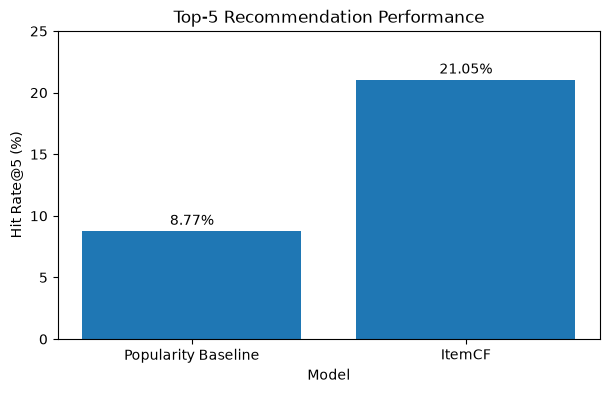

In [46]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 4))

plt.bar(
    comparison["Model"],
    comparison["Hit Rate@5"] * 100
)

plt.title("Top-5 Recommendation Performance")
plt.ylabel("Hit Rate@5 (%)")
plt.xlabel("Model")

for i, value in enumerate(comparison["Hit Rate@5"] * 100):
    plt.text(
        i,
        value + 0.5,
        f"{value:.2f}%",
        ha="center"
    )

plt.ylim(0, 25)
plt.show()

## 推荐系统小结

本部分首先构建热门商品推荐作为 Baseline，并进一步利用用户加购和购买行为构建 ItemCF 个性化推荐模型。考虑到原始数据规模较大，通过活跃用户、活跃商品和强兴趣行为筛选，将约 1.10 亿条行为数据整理为约 168.7 万个用户-商品交互对，并使用稀疏矩阵降低计算开销。

在 Leave-One-Out 离线评估中，共选取 456 名有效用户，每名用户留出 1 个真实购买商品作为测试目标。结果显示，Popularity Baseline 的 Hit Rate@5 为 8.77%，ItemCF 提升至 21.05%；Precision@5 由 1.75% 提升至 4.21%。说明基于用户历史行为的 ItemCF 相比简单热门商品推荐具有更好的个性化推荐效果。

In [47]:
# 保存推荐系统结果

popular_products_detail.to_csv(
    "../output/popular_products.csv",
    index=False
)

recommendations_detail.to_csv(
    "../output/recommendation_example.csv",
    index=False
)

comparison.to_csv(
    "../output/model_comparison.csv",
    index=False
)

print("推荐系统结果已保存到 output 文件夹")

推荐系统结果已保存到 output 文件夹
